In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [18]:
RUN_DIR = "outputs/20260719T135024Z"

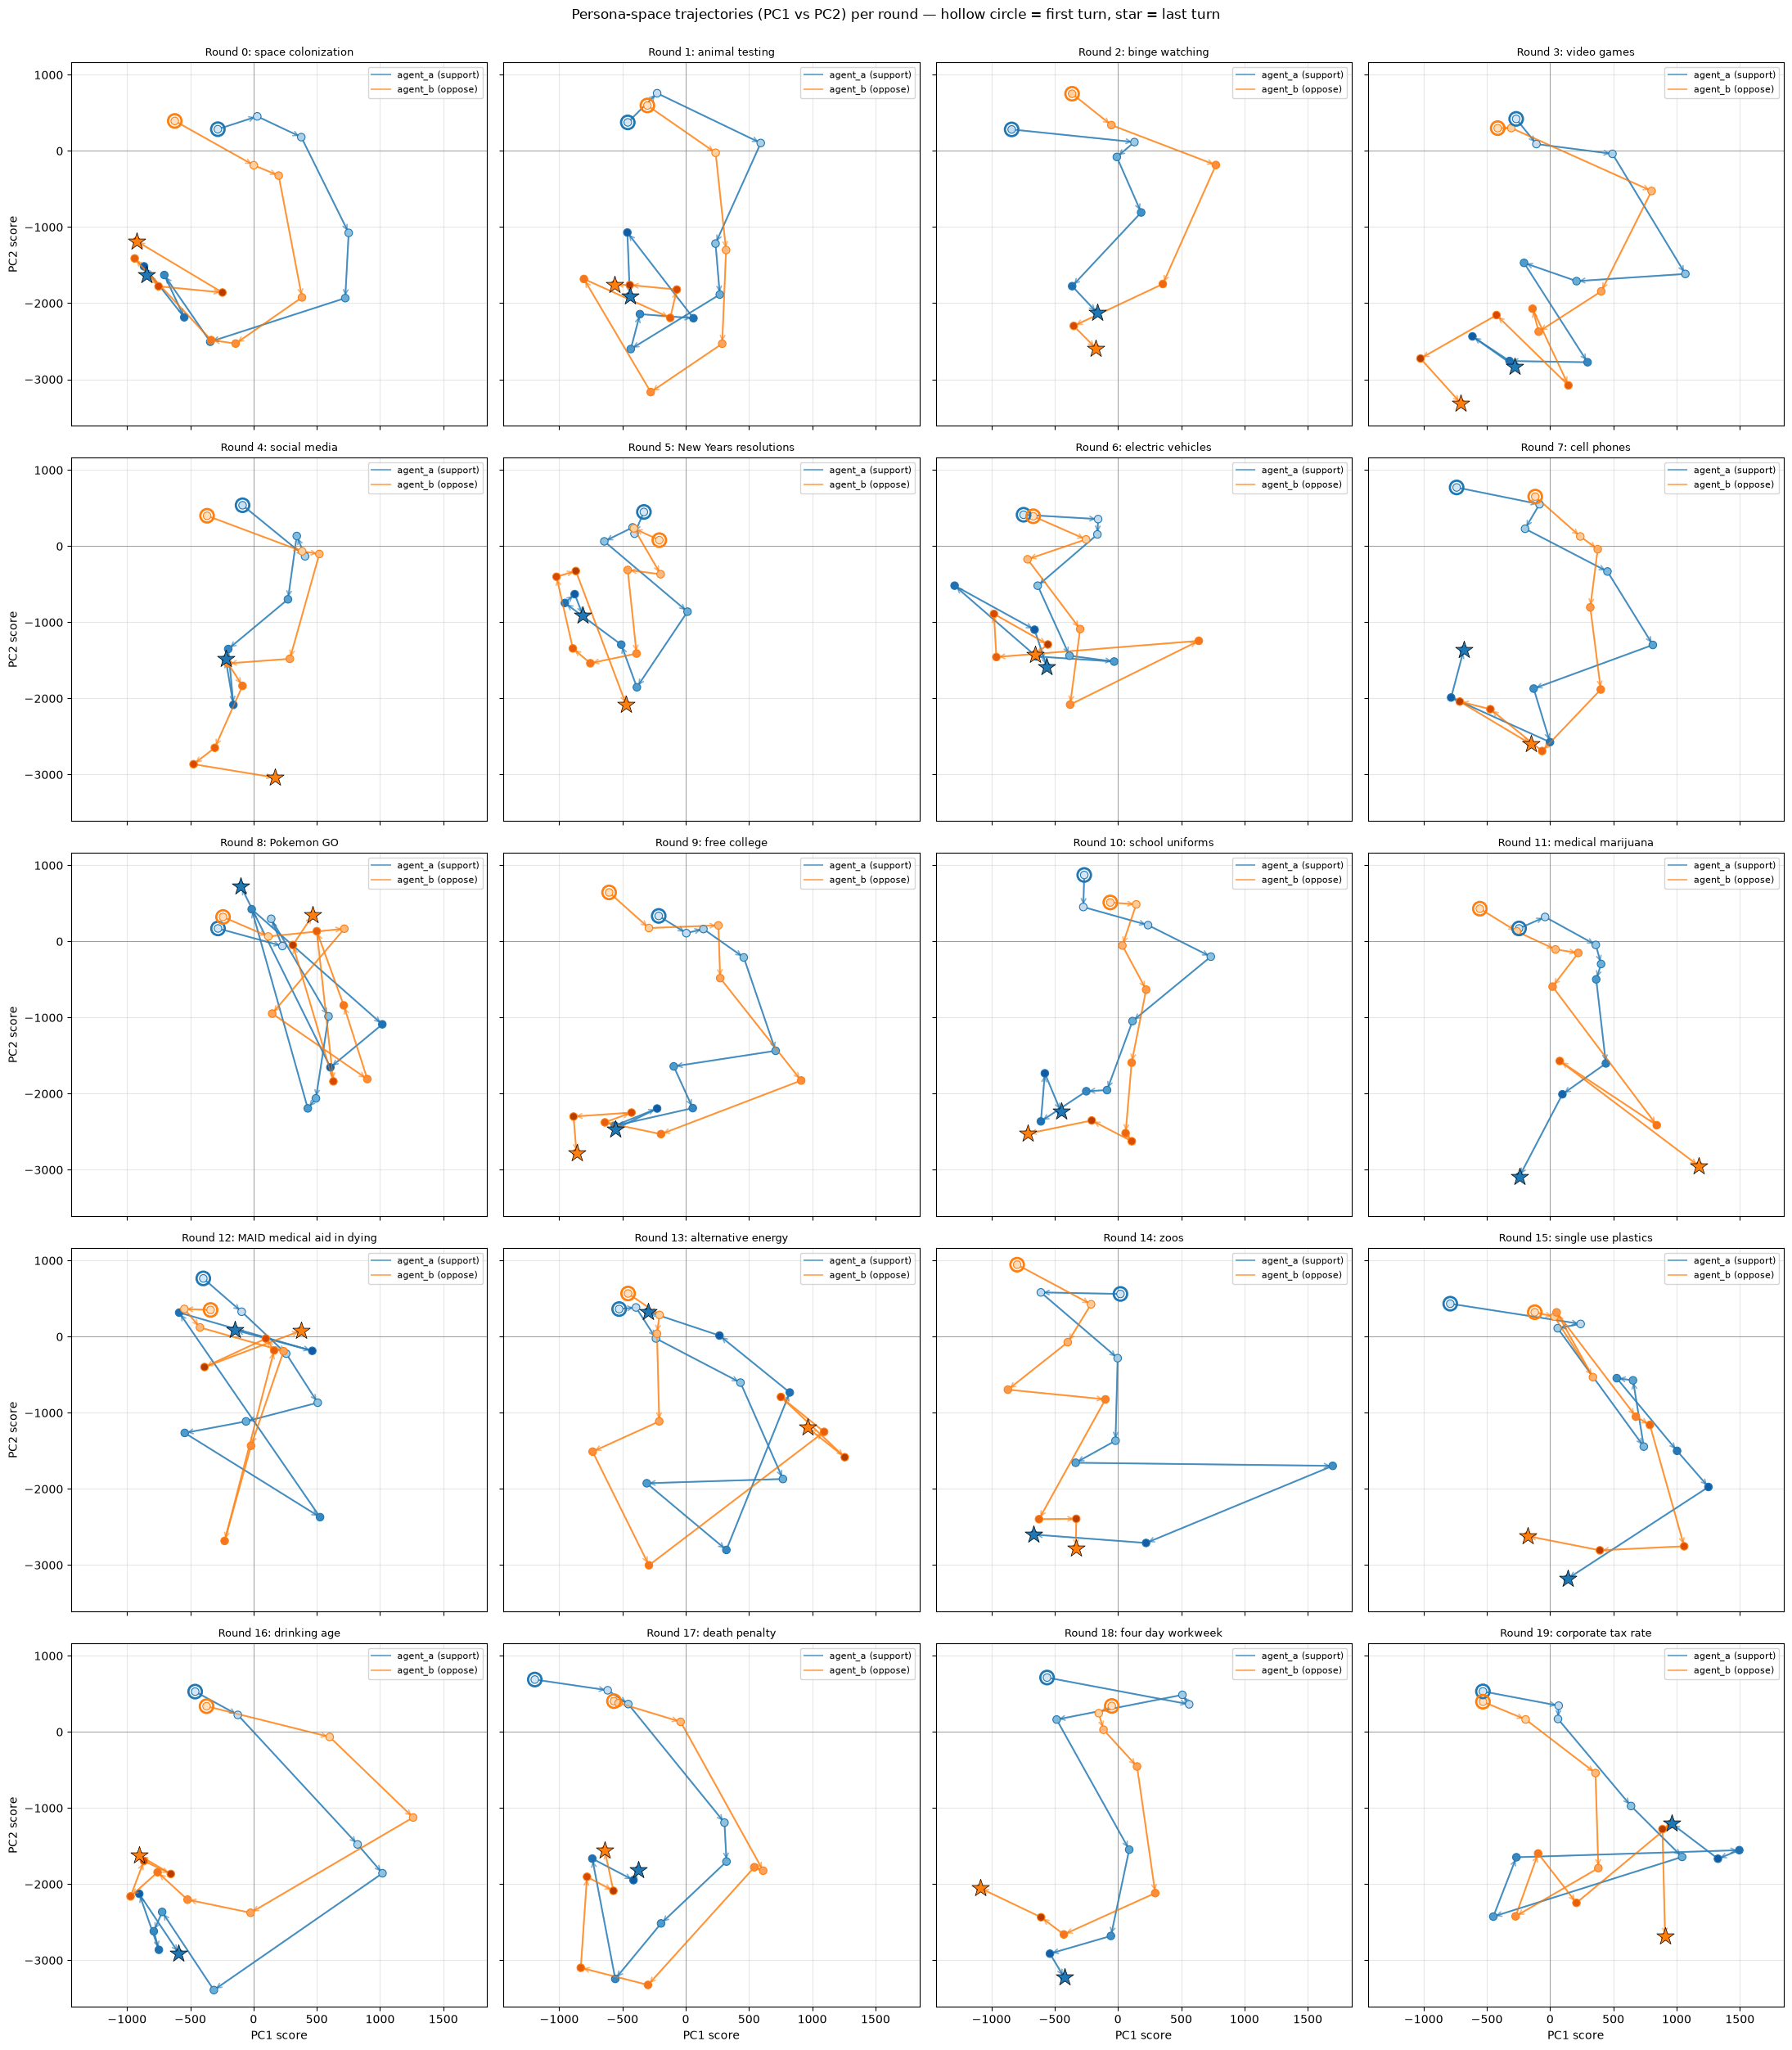

In [ ]:
df = pd.read_json(Path(RUN_DIR) / "records.jsonl", lines=True)
df = df[~df["degenerate"]].dropna(subset=["pc1_score", "pc2_score"])
 
STANCE = {"agent_a": "support", "agent_b": "oppose"}
COLOR = {"agent_a": "tab:blue", "agent_b": "tab:orange"}
CMAP = {"agent_a": "Blues", "agent_b": "Oranges"}
 
rounds = sorted(df["round_id"].unique())
ncols = min(4, len(rounds))
nrows = -(-len(rounds) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows),
                         sharex=True, sharey=True, squeeze=False)
 
slope, intercept = np.polyfit(df.n_new_tokens, df.pc2_score, 1)
df["pc2_resid"] = df.pc2_score - (slope*df.n_new_tokens + intercept)

for ax, rnd in zip(axes.flat, rounds):
    sub = df[df["round_id"] == rnd]
    for speaker, grp in sub.groupby("speaker"):
        grp = grp.sort_values("turn")
        c = COLOR[speaker]
        x, y = grp["pc1_score"].values, grp["pc2_resid"].values
 
        ax.plot(x, y, color=c, alpha=0.6, lw=1.5,
                label=f"{speaker} ({STANCE[speaker]})", zorder=2)
        for i in range(len(x) - 1):
            ax.annotate("", xy=(x[i + 1], y[i + 1]), xytext=(x[i], y[i]),
                        arrowprops=dict(arrowstyle="->", color=c, alpha=0.6, lw=1.2))
        ax.scatter(x, y, c=grp["turn"], cmap=CMAP[speaker],
                   vmin=-2, vmax=grp["turn"].max() + 1,
                   s=45, edgecolors=c, linewidths=0.8, zorder=3)
        ax.scatter(x[0], y[0], marker="o", s=140, facecolors="none",
                   edgecolors=c, linewidths=2, zorder=4)
        ax.scatter(x[-1], y[-1], marker="*", s=260, color=c,
                   edgecolors="k", linewidths=0.5, zorder=4)
 
    topic = sub["topic"].iloc[0]
    ax.set_title(f"Round {rnd}: {topic[:60]}", fontsize=9)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")
 
for ax in axes.flat[len(rounds):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("PC1 score")
for row in axes:
    row[0].set_ylabel("PC2 score")
 
fig.suptitle("Persona-space trajectories (PC1 vs PC2) per round — "
             "hollow circle = first turn, star = last turn", y=1.0)
plt.tight_layout()
plt.show()


In [16]:
ROUND_ID = 12

df = pd.read_json(Path(RUN_DIR) / "records.jsonl", lines=True)
sub = df[df["round_id"] == ROUND_ID].sort_values(["turn", "speaker"])

print(f"{sub['topic'].iloc[0]}\n{'=' * 100}")
for _, r in sub.iterrows():
    print(f"[{r['speaker']} | turn {r['turn']} | pc1 {r['pc1_score']:.0f}]")
    print(r["text"].strip() or "<empty>")
    print("=" * 100)

MAID medical aid in dying
[agent_a | turn 0 | pc1 -397]
I understand the concerns about normalizing suicide and endangering vulnerable groups. Those are valid points that deserve careful consideration. However, I believe that Medical Aid in Dying (MAID) is fundamentally different from suicide. Suicide is often impulsive and driven by despair, while MAID is a carefully considered decision made by individuals facing a terminal illness with unbearable suffering. 

The safeguards built into MAID legislation, such as requiring multiple medical opinions and psychological evaluations, are designed to protect vulnerable individuals and ensure that the decision is truly autonomous. Ultimately, I believe that allowing terminally ill individuals the choice of a peaceful and dignified death is a matter of compassion and respect for bodily autonomy. It empowers them to control their final moments and avoid prolonged suffering.
[agent_b | turn 0 | pc1 -340]
While I appreciate the sentiment of compas

In [10]:
sub

,round_id,topic,turn,speaker,text,n_new_tokens,degenerate,pc_scores,pc1_score,pc2_score,meta
